# HOLY Case Study — Analysis Notebook

This notebook contains **every computation** behind the written deliverables. Each section number is referenced
from the markdown files, so you can jump from a claim to the code that produced it.

| Deliverable | Backed by |
|---|---|
| [data-quality-review.md](docs/data-quality-review.md) | Sections **1.x** (audit) and **2** (cleaning rules) |
| [q1-campaign-analysis.md](docs/q1-campaign-analysis.md) | Sections **3.x** (analysis) and **4.x** (charts) |
| [further-analysis.md](docs/further-analysis.md) | Sections **6.x** (further analysis beyond the brief) |
| [q2-h2-budget-plan.md](docs/q2-h2-budget-plan.md) | Sections **5.x** — memo PDF extraction, transcribed MMM/attribution tables, allocation arithmetic |
| [project-plan-blueprint.md](docs/project-plan-blueprint.md) | Overall method |

**Table of contents**
- [0. Setup & data loading](#sec0)
- [1. Data quality audit](#sec1) — [1.1 orders](#sec11) · [1.2 order_items](#sec12) · [1.3 products / SKUs](#sec13) · [1.4 shipments](#sec14) · [1.5 business-event anomalies](#sec15)
- [2. Cleaning rules → analysis dataset](#sec2)
- [3. Q1 campaign analysis](#sec3) — [3.1 baseline & uplift](#sec31) · [3.2 new vs existing](#sec32) · [3.3 market breakdown](#sec33) · [3.4 daily trend](#sec34) · [3.5 category mix](#sec35) · [3.6 adoption](#sec36) · [3.7 buying behaviour](#sec37) · [3.8 cross-purchase](#sec38) · [3.9 delivery delays](#sec39) · [3.10 retention & delay impact](#sec310) · [3.11 cannibalisation](#sec311) · [3.12 3er bundle deep dive](#sec312)
- [4. Charts](#sec4)
- [5. Question 2 — H2 budget (memo analysis)](#sec5) — [5.1 PDF extraction](#sec51) · [5.2 memo tables as data](#sec52) · [5.3 derived analysis & conflicts](#sec53) · [5.4 allocation arithmetic](#sec54)
- [6. Further analysis beyond the brief](#sec6) — [6.1 refunds & cancellations](#sec61) · [6.2 May 18 sampling conversion](#sec62) · [6.3 new-customer quality](#sec63) · [6.4 warehouse split](#sec64) · [6.5 habit formation](#sec65) · [6.6 truncation-corrected delay effect](#sec66) · [6.7 refill forecast](#sec67)


<a id="sec0"></a>
## 0. Setup & data loading

Raw files are loaded untouched here; all cleaning is deferred to §2 so the audit in §1 sees the data as delivered.
`shipped_at` / `delivered_at` arrive as tz-aware UTC strings — normalised to naive timestamps once, here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)

DATA = "case-study-dataset"
orders_raw = pd.read_csv(f"{DATA}/orders.csv", parse_dates=["order_date"])
items_raw  = pd.read_csv(f"{DATA}/order_items.csv")
products   = pd.read_csv(f"{DATA}/products.csv")
ship       = pd.read_csv(f"{DATA}/shipments.csv")
ship["shipped_at"]   = pd.to_datetime(ship.shipped_at,   errors="coerce", utc=True).dt.tz_localize(None)
ship["delivered_at"] = pd.to_datetime(ship.delivered_at, errors="coerce", utc=True).dt.tz_localize(None)

print("orders:   ", orders_raw.shape)
print("items:    ", items_raw.shape)
print("products: ", products.shape)
print("shipments:", ship.shape)
print("order date range:", orders_raw.order_date.min().date(), "->", orders_raw.order_date.max().date())

orders:    (344988, 10)
items:     (1577104, 7)
products:  (502, 3)
shipments: (366217, 9)
order date range: 2026-04-01 -> 2026-05-31


<a id="sec1"></a>
## 1. Data quality audit

Findings documented in [data-quality-review.md](docs/data-quality-review.md). Each cell below produces the exact
counts quoted there.

<a id="sec11"></a>
### 1.1 `orders.csv` — duplicates, identity flags, revenue sanity

In [2]:
# Duplicate order ids (500 ids / 1000 rows; most pairs differ slightly in shipping_revenue)
dups = orders_raw[orders_raw.order_id.duplicated(keep=False)]
print("duplicated order_id rows:", orders_raw.order_id.duplicated().sum())
print("  ...ids whose duplicate rows are NOT identical:", (dups.groupby("order_id").nunique().max(axis=1) > 1).sum())

print("null customer_id:", orders_raw.customer_id.isna().sum())
print("negative net_revenue:", (orders_raw.net_revenue < 0).sum())
print("zero gross_revenue:", (orders_raw.gross_revenue == 0).sum())
print("net_revenue > gross_revenue:", (orders_raw.net_revenue > orders_raw.gross_revenue).sum())

fo = orders_raw[orders_raw.is_first_order]
print("customers (non-null id) with >1 order flagged is_first_order:", fo.groupby("customer_id").size().gt(1).sum())
fo_d = orders_raw.drop_duplicates("order_id")
print("  ...after order_id dedupe:", fo_d[fo_d.is_first_order].groupby("customer_id").size().gt(1).sum())
# note: an earlier revision reported 1,583 here - an artifact of counting null customer_ids as duplicates of each other

print("\nis_first_order vs is_first_paid_order:")
print(pd.crosstab(orders_raw.is_first_order, orders_raw.is_first_paid_order))

duplicated order_id rows: 500
  ...ids whose duplicate rows are NOT identical: 445
null customer_id: 3450
negative net_revenue: 764
zero gross_revenue: 14082
net_revenue > gross_revenue: 37098
customers (non-null id) with >1 order flagged is_first_order: 202
  ...after order_id dedupe: 0

is_first_order vs is_first_paid_order:
is_first_paid_order   False   True 
is_first_order                     
False                204214    1211
True                  10137  129426


In [3]:
# Net/gross ratio by shop: VAT-coherent overall (UK ~ 1/1.20), but for the net>gross rows
# net_revenue equals gross + shipping exactly -> the 'net' definition flips for ~11% of orders.
o_ = orders_raw[orders_raw.gross_revenue > 0].copy()
o_["ratio"] = o_.net_revenue / o_.gross_revenue
display(o_.groupby("shop")["ratio"].describe().round(3))

ng = o_[o_.ratio > 1.0001]
print("net>gross rows:", len(ng),
      "| of which net == gross + shipping (within 1 cent):",
      ((ng.net_revenue - ng.gross_revenue - ng.shipping_revenue).abs() < 0.01).sum())

,count,mean,std,min,25%,50%,75%,max
shop,,,,,,,,
DE,165723.0,0.933,0.113,-1.906,0.895,0.927,0.935,3.714
FR,129434.0,0.954,0.142,-1.934,0.905,0.938,0.948,8.901
UK,35749.0,0.862,0.136,-2.756,0.833,0.833,0.833,8.118


net>gross rows: 36996 | of which net == gross + shipping (within 1 cent): 1846


In [4]:
# RESOLVED - additional info provided by Martijn:
#   gross_revenue = SUM(item gross)                       (item-level revenue only, VAT-inclusive)
#   net_revenue   = SUM(item gross) + shipping_revenue - refunded_value - total_tax
# total_tax is not in the extract, so imply it and sanity-check against VAT rates:
imp = orders_raw[orders_raw.gross_revenue > 0].copy()
imp["implied_tax"] = imp.gross_revenue + imp.shipping_revenue - imp.refunded_value - imp.net_revenue
imp["tax_rate"] = imp.implied_tax / (imp.gross_revenue + imp.shipping_revenue)
print("implied tax rate, median by shop:", imp.groupby("shop").tax_rate.median().round(3).to_dict())
print("  (DE ~7% food VAT, FR mixes 5.5%/20%, UK 20% -> 0.2/1.2 = 16.7% of gross: formula checks out)")
print("rows where the formula implies negative tax:", (imp.implied_tax < -0.01).sum(), "(negligible)")
print("-> the audit's 'inconsistency' is fully explained. Per Martijn's follow-up guidance, the")
print("   analysis uses NET revenue as the money metric (see section 2); gross appears only in this audit.")

implied tax rate, median by shop: {'DE': 0.073, 'FR': 0.066, 'UK': 0.167}
  (DE ~7% food VAT, FR mixes 5.5%/20%, UK 20% -> 0.2/1.2 = 16.7% of gross: formula checks out)
rows where the formula implies negative tax: 7 (negligible)
-> the audit's 'inconsistency' is fully explained. Per Martijn's follow-up guidance, the
   analysis uses NET revenue as the money metric (see section 2); gross appears only in this audit.


<a id="sec12"></a>
### 1.2 `order_items.csv` — orphans, negative net, missing SKUs, reconciliation

In [5]:
print("orphan rows (order_id not in orders):", (~items_raw.order_id.isin(orders_raw.order_id)).sum())
orph = items_raw.loc[~items_raw.order_id.isin(orders_raw.order_id), "order_id"]
print("  orphan id range:", orph.min(), "->", orph.max(), " (far outside the normal ~ORD-345000 range)")

print("negative net_revenue rows (positive gross):", ((items_raw.net_revenue < 0) & (items_raw.gross_revenue >= 0)).sum())
print("is_bundle=True but ordered_sku == component_sku:", ((items_raw.ordered_sku == items_raw.component_sku) & items_raw.is_bundle).sum())

missing = items_raw.loc[~items_raw.component_sku.isin(products.sku), "component_sku"]
print("\nrows whose component_sku is missing from products.csv:", len(missing))
display(missing.value_counts().head(15))

orphan rows (order_id not in orders): 200


  orphan id range: ORD-900001 -> ORD-900200  (far outside the normal ~ORD-345000 range)
negative net_revenue rows (positive gross): 5490


is_bundle=True but ordered_sku == component_sku: 151

rows whose component_sku is missing from products.csv: 13724


component_sku
10-00-42-0020         7069
11-00-01-0043-01-1    2225
11-00-10-0139         2006
11-00-03-0016-02      1143
11-00-02-0006-02       846
NOSYNC                 144
10-00-42-0023           57
10-00-42-0024           52
10-00-42-0022           44
11-00-01-0006-04        41
10-00-42-0025           39
10-00-42-0026           35
drako-1                 10
raptor-1                 4
syru-1                   3
Name: count, dtype: int64

In [6]:
# Order-level reconciliation: gross reconciles almost perfectly; net does not at item level,
# because shipping/refunds/tax are order-level components (confirmed formula, see cell above).
item_sum = items_raw.groupby("order_id")[["gross_revenue", "net_revenue"]].sum()
rec = (orders_raw.drop_duplicates("order_id").set_index("order_id")[["gross_revenue", "net_revenue"]]
       .join(item_sum, rsuffix="_items", how="inner"))
bad_gross = (rec.gross_revenue - rec.gross_revenue_items).abs().gt(0.05).sum()
bad_net   = (rec.net_revenue   - rec.net_revenue_items).abs().gt(0.05).sum()
print(f"orders where order gross != sum(item gross) (>5 cents): {bad_gross}  ({bad_gross/len(rec):.1%})")
print(f"orders where order net   != sum(item net)   (>5 cents): {bad_net}  ({bad_net/len(rec):.1%})")

orders where order gross != sum(item gross) (>5 cents): 149  (0.0%)
orders where order net   != sum(item net)   (>5 cents): 42468  (12.3%)


<a id="sec13"></a>
### 1.3 `products.csv` & campaign SKU checks — incl. the mystery syrup-range SKU

In [7]:
BOTTLES = ["10-00-42-0001-01", "10-00-42-0001-02", "10-00-42-0001-03"]
PODS10  = "11-00-43-0001"

print("campaign hero SKUs in product master:")
for sku in BOTTLES + [PODS10]:
    row = products[products.sku == sku]
    print(" ", sku, "->", row.product_name.iloc[0] if len(row) else "MISSING")

print("\n3er bundle SKUs (brief says 'packs of 3 syrup BOTTLES'; master says 'Syrup POD - 3er Bundle'):")
display(products[products.sku.str.startswith("11-00-43-0002")])

# Mystery SKU in the syrup-bottle range, absent from the master, sold only from launch day
m20 = items_raw[items_raw.component_sku == "10-00-42-0020"].merge(
    orders_raw.drop_duplicates("order_id")[["order_id", "order_date", "shop"]], on="order_id")
print("10-00-42-0020: rows:", len(m20), "| dates:", m20.order_date.min().date(), "->", m20.order_date.max().date(),
      "| avg price:", round(m20.gross_revenue.sum() / m20.quantity.sum(), 2), "| by shop:", m20.shop.value_counts().to_dict())
print("RESOLVED - additional info provided by Martijn: all 10-00-42-002x SKUs are spare parts (replacements) for the syrup bottle,")
print("intentionally absent from the product master -> excluded from the analysis dataset in section 2.")

campaign hero SKUs in product master:
  10-00-42-0001-01 -> HOLY Syrup Bottle - Darko
  10-00-42-0001-02 -> HOLY Syrup Bottle - Syru
  10-00-42-0001-03 -> HOLY Syrup Bottle - Raptor
  11-00-43-0001 -> Syrup - Mixed 10 Pack - Pods 

3er bundle SKUs (brief says 'packs of 3 syrup BOTTLES'; master says 'Syrup POD - 3er Bundle'):


,sku,product_name,category
492,11-00-43-0002-01,Syrup Pod - 3er Bundle - Green Apple,43 - Syrup Bundle
493,11-00-43-0002-02,Syrup Pod - 3er Bundle - Elderflower Lime,43 - Syrup Bundle
494,11-00-43-0002-03,Syrup Pod - 3er Bundle - Cola Ice Pop,43 - Syrup Bundle
495,11-00-43-0002-04,Syrup Pod - 3er Bundle - Raspberry,43 - Syrup Bundle
496,11-00-43-0002-05,Syrup Pod - 3er Bundle - Peach,43 - Syrup Bundle
497,11-00-43-0002-06,Syrup Pod - 3er Bundle - Grapefruit,43 - Syrup Bundle
498,11-00-43-0002-07,Syrup Pod - 3er Bundle - Pomegranate,43 - Syrup Bundle
499,11-00-43-0002-08,Syrup Pod - 3er Bundle - Strawberry,43 - Syrup Bundle
500,11-00-43-0002-09,Syrup Pod - 3er Bundle - Mango,43 - Syrup Bundle
501,11-00-43-0002-10,Syrup Pod - 3er Bundle - Tangerine Yuzu,43 - Syrup Bundle


10-00-42-0020: rows: 7067 | dates: 2026-04-19 -> 2026-05-31 | avg price: 4.13 | by shop: {'DE': 4470, 'FR': 2059, 'UK': 538}
RESOLVED - additional info provided by Martijn: all 10-00-42-002x SKUs are spare parts (replacements) for the syrup bottle,
intentionally absent from the product master -> excluded from the analysis dataset in section 2.


<a id="sec14"></a>
### 1.4 `shipments.csv` — duplicates / re-shipments, statuses, broken `is_on_time`

In [8]:
sc = ship.order_id.value_counts()
print("orders with >1 shipment row:", (sc > 1).sum(), "| max rows per order:", sc.max())
print("orders with NO shipment row:", (~orders_raw.order_id.isin(ship.order_id)).sum())
print("\nshipment_status:"); print(ship.shipment_status.value_counts().to_string())

# typical multi-row pattern: shipped -> cancelled -> shipped again weeks later (replacements?)
example = ship[ship.order_id.isin(sc[sc > 2].index)].sort_values(["order_id", "shipped_at"]).head(6)
display(example[["order_id", "shipment_status", "delivery_status", "shipped_at", "delivered_at"]])

orders with >1 shipment row: 21555 | max rows per order: 4
orders with NO shipment row: 270

shipment_status:
shipment_status
shipped                357720
waiting_for_picking      6551
cancelled                1649
picked                    215
ignored                    39
in_picking                 36
on_hold                     7


,order_id,shipment_status,delivery_status,shipped_at,delivered_at
251851,ORD-074731,shipped,Delivered,2026-04-23 11:01:35.932894,2026-04-29 10:33:00
54626,ORD-074731,shipped,Delivered,2026-05-18 13:44:33.075344,2026-05-21 11:19:00
143778,ORD-074731,cancelled,NaN,NaT,NaT
283983,ORD-075492,shipped,Delivered,2026-04-23 12:40:34.578728,2026-04-28 15:05:00
104971,ORD-075492,shipped,Delivered,2026-05-18 13:53:36.838057,2026-05-21 15:33:00
319101,ORD-075492,cancelled,NaN,NaT,NaT


In [9]:
s2 = ship.merge(orders_raw.drop_duplicates("order_id")[["order_id", "order_date"]], on="order_id", how="left")
print("delivered before order date:", (s2.delivered_at < s2.order_date).sum())
print("delivered before shipped:", (s2.delivered_at < s2.shipped_at).sum())
print("negative days_to_delivery:", (s2.days_to_delivery < 0).sum())

# is_on_time is ~98% False even for 1-2 day deliveries -> unusable
print("\nis_on_time value counts:"); print(ship.is_on_time.value_counts(dropna=False).to_string())

# days_to_delivery disagrees with (delivered_at - order_date) -> it is anchored to shipped_at, not order date
s2["calc_days"] = (s2.delivered_at - s2.order_date).dt.days
mask = s2.days_to_delivery.notna() & s2.calc_days.notna()
print("\nrows where days_to_delivery differs from delivered-order by >1 day:",
      (s2.loc[mask, "days_to_delivery"] - s2.loc[mask, "calc_days"]).abs().gt(1).sum(), "of", mask.sum(),
      "-> delay is computed manually in this analysis")

delivered before order date: 0
delivered before shipped: 1
negative days_to_delivery: 1

is_on_time value counts:
is_on_time
False    344406
NaN       16164
True       5647

rows where days_to_delivery differs from delivered-order by >1 day: 145447 of 350133 -> delay is computed manually in this analysis


<a id="sec15"></a>
### 1.5 Business-event anomalies (not errors — need business context)

Three calendar events distort naive period comparisons; all three are excluded or caveated in the write-up.

In [10]:
oo = orders_raw.drop_duplicates("order_id")

# May 18: sampling giveaway? 56% zero-revenue orders, 72% first-time customers, AOV ~ EUR 31
d18 = oo[oo.order_date == "2026-05-18"]
print(f"May 18: {len(d18)} orders | AOV {d18.gross_revenue.mean():.2f} | zero-gross {(d18.gross_revenue == 0).mean():.1%} | first-order {d18.is_first_order.mean():.1%}")

# May 27: a separate 'Summer Cocktail 2026' launch
d27_items = items_raw[items_raw.order_id.isin(oo.loc[oo.order_date == "2026-05-27", "order_id"])]
top27 = (d27_items.merge(products, left_on="component_sku", right_on="sku", how="left")
         .groupby("product_name").quantity.sum().nlargest(5))
d27 = oo[oo.order_date == "2026-05-27"]
print(f"\nMay 27: {len(d27)} orders | AOV {d27.gross_revenue.mean():.2f} | top products:")
print(top27.to_string())

# Pre-launch syrup sales (before Apr 19) and early zero-revenue 3er rows (before the May 12 launch)
BOTTLES = ["10-00-42-0001-01", "10-00-42-0001-02", "10-00-42-0001-03"]
sy = items_raw[items_raw.component_sku.isin(BOTTLES)].merge(oo[["order_id", "order_date"]], on="order_id")
print("\nsyrup bottle rows before Apr 19:", (sy.order_date < "2026-04-19").sum())
b3 = items_raw[items_raw.ordered_sku.str.startswith("11-00-43-0002")].merge(oo[["order_id", "order_date"]], on="order_id")
pre3 = b3[b3.order_date < "2026-05-12"]
print(f"3er-bundle rows before May 12: {len(pre3)} (gross EUR {pre3.gross_revenue.sum():.0f} -> zero-value seeds/samples)")

May 18: 9965 orders | AOV 31.29 | zero-gross 55.7% | first-order 72.3%



May 27: 12159 orders | AOV 103.96 | top products:
product_name
Ice Cube Tray - Summer Cocktail 2026              8692
Beach Towel - Summer Cocktail 2026 - 60x120 cm    5775
Energy - Caipirinha Crab - Tub 50 Portions        3512
Energy - Mojito Macaw - Tub 50 Portions           3160
Mixed Sachet Box - Cocktails - 12 Portions        3067



syrup bottle rows before Apr 19: 2


3er-bundle rows before May 12: 155 (gross EUR 27 -> zero-value seeds/samples)


<a id="sec2"></a>
## 2. Cleaning rules → analysis dataset

The rules documented in [data-quality-review.md §5](docs/data-quality-review.md):
dedupe orders · drop orphan items · exclude cancelled orders (**rule provided by Martijn: `refunded_value >= gross_revenue`**,
guarded to `gross > 0` so zero-value sample orders aren't swept up) · drop `10-00-42-002x` spare-part line items
(per Martijn: out of scope) · money metric = **net revenue** (additional info provided by Martijn: what marketing steers on;
gross appears only in the §1 audit) · periods **pre** Apr 1–18 / **campaign** Apr 19–May 4 / **post** May 5–31.

In [11]:
orders = orders_raw.drop_duplicates("order_id").copy()

# cancelled orders - rule confirmed by Martijn: a fully refunded order is a cancellation.
# Guard to gross > 0: zero-value sample orders (e.g. the May 18 giveaway) trivially satisfy refunded >= gross.
orders["cancelled"] = (orders.gross_revenue > 0) & (orders.refunded_value >= orders.gross_revenue)
print("orders deduped:", len(orders), "| cancelled by refund rule (excluded):", orders.cancelled.sum())

o = orders[~orders.cancelled].copy()
print("negative net_revenue remaining among active orders:", (o.net_revenue < 0).sum(),
      "(edge cases where refund exceeds gross+shipping-tax; negligible)")

def period(d):
    if d <= pd.Timestamp("2026-04-18"): return "1_pre"
    if d <= pd.Timestamp("2026-05-04"): return "2_campaign"
    return "3_post"
o["period"] = o.order_date.apply(period)
PERIOD_DAYS = pd.Series({"1_pre": 18, "2_campaign": 16, "3_post": 27})

# enriched line items: only active orders, joined to order context and product master
items = items_raw[items_raw.order_id.isin(o.order_id)].copy()
items = items[~items.component_sku.str.startswith("10-00-42-002")]   # syrup spare parts: per Martijn: out of scope
items = items.merge(o[["order_id", "order_date", "shop", "customer_id", "is_first_order", "period"]], on="order_id")
items = items.merge(products, left_on="component_sku", right_on="sku", how="left")
items["cat"] = items.category.fillna("UNKNOWN")

BOTTLES = ["10-00-42-0001-01", "10-00-42-0001-02", "10-00-42-0001-03"]
PODS10  = "11-00-43-0001"
bot = items[items.component_sku.isin(BOTTLES)]
o["has_bottle"] = o.order_id.isin(set(bot.order_id))
camp = o[o.period == "2_campaign"]
print("active orders:", len(o), "| enriched items:", len(items), "| campaign orders:", len(camp))

orders deduped: 344488 | cancelled by refund rule (excluded): 838


negative net_revenue remaining among active orders: 61 (edge cases where refund exceeds gross+shipping-tax; negligible)


active orders: 343650 | enriched items: 1565920 | campaign orders: 125252


<a id="sec3"></a>
## 3. Q1 — campaign analysis
Backs [q1-campaign-analysis.md](docs/q1-campaign-analysis.md) section by section.

<a id="sec31"></a>
### 3.1 Baseline & uplift (per-day averages; unequal window lengths)

In [12]:
agg = o.groupby("period").agg(orders_n=("order_id", "count"), net=("net_revenue", "sum"),
                              aov=("net_revenue", "mean"), first_share=("is_first_order", "mean"))
agg["days"] = PERIOD_DAYS
agg["orders_per_day"] = (agg.orders_n / agg.days).round(0)
agg["net_per_day"]  = (agg.net / agg.days).round(0)
display(agg.round(3))

up = lambda a, b: agg.loc[a, "net_per_day"] / agg.loc[b, "net_per_day"] - 1
upo = lambda a, b: agg.loc[a, "orders_per_day"] / agg.loc[b, "orders_per_day"] - 1
print(f"campaign vs pre: orders/day {upo('2_campaign','1_pre'):+.0%} | revenue/day {up('2_campaign','1_pre'):+.0%}")
print(f"post vs pre:     orders/day {upo('3_post','1_pre'):+.0%} | revenue/day {up('3_post','1_pre'):+.0%}")

camp_nl = o[(o.period == "2_campaign") & (o.order_date != "2026-04-19")]   # excluding launch day
print(f"campaign excl. launch day: orders/day {len(camp_nl)/15:,.0f} ({len(camp_nl)/15/agg.loc['1_pre','orders_per_day']-1:+.0%}), "
      f"net rev/day {camp_nl.net_revenue.sum()/15:,.0f} ({camp_nl.net_revenue.sum()/15/agg.loc['1_pre','net_per_day']-1:+.0%})")
launch_orders = agg.loc["2_campaign", "orders_n"] - len(camp_nl)
print(f"launch day (Apr 19): {launch_orders:,.0f} orders = {launch_orders/agg.loc['2_campaign','orders_n']:.0%} of all campaign orders in a single day")

# per market
m = o.groupby(["period", "shop"]).net_revenue.sum().unstack("period")
m = m.div(PERIOD_DAYS, axis=1).round(0)
m["camp_uplift"]  = (m["2_campaign"] / m["1_pre"] - 1).map("{:+.0%}".format)
m["post_vs_pre"] = (m["3_post"] / m["1_pre"] - 1).map("{:+.0%}".format)
display(m)

,orders_n,net,aov,first_share,days,orders_per_day,net_per_day
period,,,,,,,
1_pre,72813,4823467.36,66.245,0.469,18,4045.0,267970.0
2_campaign,125252,9357372.89,74.708,0.366,16,7828.0,584836.0
3_post,145585,10054958.04,69.066,0.407,27,5392.0,372406.0


campaign vs pre: orders/day +94% | revenue/day +118%
post vs pre:     orders/day +33% | revenue/day +39%
campaign excl. launch day: orders/day 6,052 (+50%), net rev/day 420,048 (+57%)
launch day (Apr 19): 34,479 orders = 28% of all campaign orders in a single day


period,1_pre,2_campaign,3_post,camp_uplift,post_vs_pre
shop,,,,,
DE,125311.0,355696.0,195413.0,+184%,+56%
FR,119025.0,180109.0,142030.0,+51%,+19%
UK,23635.0,49032.0,34963.0,+107%,+48%


**Sensitivity checks** — reviewer-proofing the baseline: the pre-period contains Easter (Apr 3–6) and the
campaign contains May 1; zero-revenue sample orders (concentrated on May 18) sit inside the post-period.

In [13]:
# (a) calendar effects
easter = pd.date_range("2026-04-03", "2026-04-06")
pre_x = o[(o.period == "1_pre") & (~o.order_date.isin(easter))].net_revenue.sum() / 14
camp_x = o[(o.period == "2_campaign") & (~o.order_date.isin(pd.to_datetime(["2026-04-19", "2026-05-01"])))].net_revenue.sum() / 14
print(f"(a) uplift vs Easter-adjusted baseline: {agg.loc['2_campaign','net_per_day']/pre_x-1:+.0%} (headline +118%);")
print(f"    excl. launch day AND May 1: {camp_x/pre_x-1:+.0%} (headline +57%) -> calendar shaves a few points; direction robust")

# (b) zero-revenue orders inflate order counts, not revenue
oz = o[o.gross_revenue > 0]
na = o.groupby("period").order_id.count() / PERIOD_DAYS
nz = oz.groupby("period").order_id.count() / PERIOD_DAYS
rz = oz.groupby("period").net_revenue.sum() / PERIOD_DAYS
print(f"(b) zero-revenue orders by period: {(o.gross_revenue == 0).groupby(o.period).sum().to_dict()}")
print(f"    post orders/day {na['3_post']/na['1_pre']-1:+.0%} incl vs {nz['3_post']/nz['1_pre']-1:+.0%} excl them;")
print(f"    post AOV {o[o.period == '3_post'].net_revenue.mean():.1f} incl vs {oz[oz.period == '3_post'].net_revenue.mean():.1f} excl;")
print(f"    post net revenue/day {rz['3_post']/rz['1_pre']-1:+.0%} excluding them (headline +39%) - revenue is unaffected")

(a) uplift vs Easter-adjusted baseline: +114% (headline +118%);
    excl. launch day AND May 1: +54% (headline +57%) -> calendar shaves a few points; direction robust


(b) zero-revenue orders by period: {'1_pre': 938, '2_campaign': 1475, '3_post': 11654}
    post orders/day +33% incl vs +24% excl them;
    post AOV 69.1 incl vs 75.1 excl;
    post net revenue/day +39% excluding them (headline +39%) - revenue is unaffected


<a id="sec32"></a>
### 3.2 Existing vs new customers

In [14]:
print("first-order share by period:")
print(o.groupby("period").is_first_order.mean().map("{:.1%}".format).to_string())
print(f"\ncampaign: bottle orders {camp[camp.has_bottle].is_first_order.mean():.1%} first-time "
      f"vs non-bottle {camp[~camp.has_bottle].is_first_order.mean():.1%} "
      "-> the launch activated EXISTING customers")

first-order share by period:
period
1_pre         46.9%
2_campaign    36.6%
3_post        40.7%

campaign: bottle orders 22.7% first-time vs non-bottle 47.8% -> the launch activated EXISTING customers


<a id="sec33"></a>
### 3.3 Market breakdown (syrup adoption)

In [15]:
camp_bot = bot[bot.period == "2_campaign"]
mk = camp_bot.groupby("shop").agg(units=("quantity", "sum"), net=("net_revenue", "sum"), orders_n=("order_id", "nunique"))
mk["units_share"] = (mk.units / mk.units.sum() * 100).round(1)
mk["penetration_pct"] = (mk.orders_n / camp.groupby("shop").order_id.count() * 100).round(1)
display(mk)
print(f"overall campaign bottle penetration: {camp.has_bottle.mean():.1%}")

,units,net,orders_n,units_share,penetration_pct
shop,,,,,
DE,46846,1280148.57,40491,73.9,57.0
FR,13537,365342.00,12592,21.4,30.5
UK,2973,94186.71,2899,4.7,22.4


overall campaign bottle penetration: 44.7%


<a id="sec34"></a>
### 3.4 Daily trend — bottle units

In [16]:
daily_bottles = bot.groupby("order_date").quantity.sum()
launch = daily_bottles.loc[pd.Timestamp("2026-04-19")]
print(f"launch day: {launch:,} bottles = {launch / camp_bot.quantity.sum():.0%} of campaign volume")
print(f"campaign tail (Apr 25-May 4) avg: {daily_bottles.loc['2026-04-25':'2026-05-04'].mean():,.0f}/day")
print(f"post-campaign (May 5-31) avg:     {daily_bottles.loc['2026-05-05':].mean():,.0f}/day")
display(daily_bottles.to_frame("bottle_units").T)

launch day: 31,723 bottles = 50% of campaign volume
campaign tail (Apr 25-May 4) avg: 1,434/day
post-campaign (May 5-31) avg:     723/day


order_date,2026-04-16,2026-04-17,2026-04-19,2026-04-20,2026-04-21,2026-04-22,2026-04-23,2026-04-24,2026-04-25,2026-04-26,...,2026-05-22,2026-05-23,2026-05-24,2026-05-25,2026-05-26,2026-05-27,2026-05-28,2026-05-29,2026-05-30,2026-05-31
bottle_units,1,1,31723,5391,3896,3192,2649,2165,1815,1614,...,405,431,417,457,457,900,682,620,591,604


<a id="sec35"></a>
### 3.5 Category mix (share of net revenue by period)

In [17]:
cm = items.pivot_table(index="cat", columns="period", values="net_revenue", aggfunc="sum", fill_value=0)
cms = (cm / cm.sum() * 100).round(1)
display(cms[cms["2_campaign"] > 0.5].sort_values("2_campaign", ascending=False))

energy_cats = ["01 - Energy Bundle", "04 - Energy Sachet", "07 - Energy Sachetbox"]
en_day = items[items.cat.isin(energy_cats)].groupby("period").net_revenue.sum() / PERIOD_DAYS
print("energy (3 cats) net rev/day by period:", en_day.round(0).to_dict(), " -> absolute energy demand GREW")
print("note: in NET terms the bottle (standard-VAT hardware) shrinks vs food-VAT consumables -> the Energy")
print("      Bundle category edges the Syrup Bottle as top single category; the syrup franchise remains #1 combined")

period,1_pre,2_campaign,3_post
cat,,,
01 - Energy Bundle,26.8,20.2,26.4
42 - Syrup Bottle,0.0,18.8,5.5
43 - Syrup Bundle,0.0,15.4,7.9
35 - Mixed Sachetbox,27.3,14.7,17.3
03 - Hydration Bundle,15.3,10.5,14.3
02 - Iced Tea Bundle,12.3,9.0,11.0
10 - Shaker,8.3,5.2,7.4
07 - Energy Sachetbox,2.3,1.5,2.2
32 - Milkshake Bundle,2.0,1.4,2.3


energy (3 cats) net rev/day by period: {'1_pre': 78344.0, '2_campaign': 127573.0, '3_post': 106666.0}  -> absolute energy demand GREW
note: in NET terms the bottle (standard-VAT hardware) shrinks vs food-VAT consumables -> the Energy
      Bundle category edges the Syrup Bottle as top single category; the syrup franchise remains #1 combined


<a id="sec36"></a>
### 3.6 Adoption — penetration, flavours, bundle architecture, attach rates

In [18]:
print(f"campaign orders with a bottle: {camp.has_bottle.sum():,} of {len(camp):,} ({camp.has_bottle.mean():.1%})")
print(f"bottles sold in campaign: {camp_bot.quantity.sum():,}")

fl = camp_bot.groupby("product_name").quantity.sum()
print("\nflavour split:"); print((fl / fl.sum()).map("{:.0%}".format).to_string())

print("\nbottle rows by is_bundle:", camp_bot.is_bundle.value_counts().to_dict(), " -> 100% sold via bundle")
camp_items = items[items.period == "2_campaign"]
pods_orders = set(camp_items.loc[camp_items.component_sku == PODS10, "order_id"])
bot_orders = set(camp_bot.order_id)
print(f"pods attach rate among bottle orders: {len(pods_orders & bot_orders) / len(bot_orders):.1%}")
print(f"pod packs sold WITHOUT a bottle: {len(pods_orders - bot_orders)}")
stick = set(camp_items.loc[camp_items.cat == "13 - Sticker", "order_id"])
print(f"sticker attach rate among bottle orders: {len(stick & bot_orders) / len(bot_orders):.1%}")
print("\nnote: pods/sticker 'attach' is DEFINITIONAL - the launch offer was a fixed bundle. The behavioural")
print("      signals are near-zero standalone demand (94 pod packs without a bottle) and the refill loop it")
print("      seeds for every owner (section 3.10).")

campaign orders with a bottle: 55,982 of 125,252 (44.7%)
bottles sold in campaign: 63,356

flavour split:
product_name
HOLY Syrup Bottle - Darko     49%
HOLY Syrup Bottle - Raptor    17%
HOLY Syrup Bottle - Syru      34%

bottle rows by is_bundle: {True: 63356}  -> 100% sold via bundle


pods attach rate among bottle orders: 99.8%
pod packs sold WITHOUT a bottle: 94
sticker attach rate among bottle orders: 80.7%

note: pods/sticker 'attach' is DEFINITIONAL - the launch offer was a fixed bundle. The behavioural
      signals are near-zero standalone demand (94 pod packs without a bottle) and the refill loop it
      seeds for every owner (section 3.10).


<a id="sec37"></a>
### 3.7 Buying behaviour

In [19]:
bp = camp_bot.groupby("order_id").quantity.sum()
print(f"bottles per bottle-order: mean {bp.mean():.2f}")
print((bp.value_counts(normalize=True).head(4)).map("{:.1%}".format).to_string())
print(f"\nAOV (net) bottle orders {camp[camp.has_bottle].net_revenue.mean():.2f} "
      f"vs non-bottle campaign orders {camp[~camp.has_bottle].net_revenue.mean():.2f}")
print("(the net premium is smaller than in gross terms: the bottle is standard-VAT hardware, consumables are food-VAT)")

bottles per bottle-order: mean 1.13


quantity
1    88.4%
2    10.2%
3     1.3%
4     0.1%

AOV (net) bottle orders 81.34 vs non-bottle campaign orders 69.35
(the net premium is smaller than in gross terms: the bottle is standard-VAT hardware, consumables are food-VAT)


<a id="sec38"></a>
### 3.8 Cross-purchase (what else is in a bottle basket)

In [20]:
cross = camp_items[camp_items.order_id.isin(bot_orders) & ~camp_items.component_sku.isin(BOTTLES)]
share = (cross.groupby("cat").order_id.nunique() / len(bot_orders)).sort_values(ascending=False)
print(share.head(8).map("{:.1%}".format).to_string())
print(f"\nbottle-bundle-only orders (nothing else): {1 - cross.order_id.nunique() / len(bot_orders):.1%}")

cat
43 - Syrup Bundle        99.9%
13 - Sticker             80.7%
10 - Shaker              30.0%
11 - Merch               23.7%
01 - Energy Bundle       16.0%
02 - Iced Tea Bundle      9.1%
03 - Hydration Bundle     8.9%
35 - Mixed Sachetbox      7.3%



bottle-bundle-only orders (nothing else): 0.1%


<a id="sec39"></a>
### 3.9 Delivery delays — the production gap

Delay = `delivered_at − order_date` of the **first delivered** shipment (raw `days_to_delivery`/`is_on_time` are unusable, see §1.4).

In [21]:
first_ship = ship[ship.delivered_at.notna()].sort_values("delivered_at").groupby("order_id").head(1)
od = o.merge(first_ship[["order_id", "delivered_at"]], on="order_id", how="left")
od["lag"] = (od.delivered_at - od.order_date).dt.days

camp_od = od[od.period == "2_campaign"]
display(camp_od.groupby("has_bottle").lag.describe().round(1))
for thr in [7, 14]:
    print(f"share delayed >{thr}d: bottle {(camp_od[camp_od.has_bottle].lag > thr).mean():.1%} "
          f"vs non-bottle {(camp_od[~camp_od.has_bottle].lag > thr).mean():.1%}")

bo = od[od.has_bottle]
wk = bo.groupby(bo.order_date.dt.isocalendar().week).lag.agg(["count", "median", "mean"]).round(1)
print("\nbottle-order delivery lag by ISO order week (weeks 18-19 = the production gap):")
print(wk.to_string())

,count,mean,std,min,25%,50%,75%,max
has_bottle,,,,,,,,
False,68688.0,5.1,3.1,1.0,3.0,4.0,6.0,61.0
True,55098.0,12.8,12.6,1.0,4.0,8.0,16.0,62.0


share delayed >7d: bottle 51.6% vs non-bottle 14.6%
share delayed >14d: bottle 29.5% vs non-bottle 0.7%

bottle-order delivery lag by ISO order week (weeks 18-19 = the production gap):
      count  median  mean
week                     
16    26707     5.0   6.2
17    18623    15.0  14.5
18     8855    40.0  27.7
19     5585    38.0  26.3
20     3460     5.0   5.8
21     1452     7.0   7.0
22     2951     6.0   5.8


<a id="sec310"></a>
### 3.10 Retention, reorders & the cost of late delivery

Cohort: campaign bottle buyers with a `customer_id` (first bottle order per customer). A reorder = any later
purchase of a bottle, 10er pods, or a 3er bundle (`11-00-43-0002%`, per the brief's rule).

In [22]:
camp_buyers = o[(o.period == "2_campaign") & o.has_bottle & o.customer_id.notna()]
cohort = camp_buyers.sort_values("order_date").groupby("customer_id").first().reset_index()
print("identifiable campaign bottle buyers:", len(cohort))

syr_any = items[items.component_sku.isin(BOTTLES + [PODS10]) | items.ordered_sku.str.startswith("11-00-43-0002")]
later = syr_any.merge(cohort[["customer_id", "order_date"]].rename(columns={"order_date": "first_bottle_date"}), on="customer_id")
later = later[later.order_date > later.first_bottle_date]

reorderers = set(later.customer_id)
print(f"reordered syrup by May 31: {len(reorderers):,} ({len(reorderers)/len(cohort):.1%})")

later["rtype"] = "bottle"
later.loc[later.component_sku == PODS10, "rtype"] = "pods 10er"
later.loc[later.ordered_sku.str.startswith("11-00-43-0002"), "rtype"] = "3er pod bundle"
print("\nreorder vehicle (customers, overlapping):"); print(later.groupby("rtype").customer_id.nunique().to_string())

tt = later.groupby("customer_id").order_date.min() - cohort.set_index("customer_id").order_date
print(f"\nmedian days to first reorder: {tt.dt.days.median():.0f}")

identifiable campaign bottle buyers: 54127


reordered syrup by May 31: 5,470 (10.1%)

reorder vehicle (customers, overlapping):
rtype
3er pod bundle    3992
bottle            2072
pods 10er         1978

median days to first reorder: 23


In [23]:
# Reorder rate by delivery delay of the FIRST bottle order
cb = cohort.merge(od[["order_id", "lag"]], on="order_id", how="left")
cb["reordered"] = cb.customer_id.isin(reorderers)
cb["delay_bucket"] = pd.cut(cb.lag, [-1, 4, 7, 14, 100], labels=["0-4d", "5-7d", "8-14d", ">14d"])
delay_tbl = cb.groupby("delay_bucket", observed=True).agg(n=("customer_id", "count"), reorder_rate=("reordered", "mean"))
display(delay_tbl.round(4))

# counterfactual: if every bucket reordered at the 0-4d rate
best = delay_tbl.reorder_rate.iloc[0]
lost = (delay_tbl.n * (best - delay_tbl.reorder_rate)).clip(lower=0).sum()
print(f"reorders lost vs 0-4d service level: ~{lost:,.0f} customers (~{lost/len(cohort):.1%} of cohort)")
print("caveat: later orderers also had less time to reorder before May 31 -> true causal effect somewhat smaller")

,n,reorder_rate
delay_bucket,,
0-4d,14654,0.1456
5-7d,10779,0.1106
8-14d,12070,0.0969
>14d,15813,0.0544


reorders lost vs 0-4d service level: ~2,406 customers (~4.4% of cohort)
caveat: later orderers also had less time to reorder before May 31 -> true causal effect somewhat smaller


In [24]:
# internal benchmark: same-window category repeat for the established core category (energy).
# The naive cohort overlaps the syrup cohort (~30% of campaign energy buyers also bought a bottle - the
# most engaged multi-category fans), so also compute a CLEAN control excluding bottle buyers.
en_b = items[items.cat.isin(["01 - Energy Bundle", "04 - Energy Sachet", "07 - Energy Sachetbox"])]
en_first = en_b[(en_b.period == "2_campaign") & en_b.customer_id.notna()].sort_values("order_date").groupby("customer_id").order_date.first()
later_en = en_b.merge(en_first.rename("first_en"), on="customer_id")
later_en = later_en[later_en.order_date > later_en.first_en]
rep_all = later_en.customer_id.nunique() / len(en_first)

bottle_cust = set(bot.customer_id.dropna())
mask = en_first.index.isin(bottle_cust)
clean_idx = set(en_first[~mask].index)
rep_clean = later_en[later_en.customer_id.isin(clean_idx)].customer_id.nunique() / (~mask).sum()
rep_btl = later_en[later_en.customer_id.isin(bottle_cust)].customer_id.nunique() / mask.sum()
print(f"benchmark: campaign ENERGY buyers re-buying energy by May 31: {rep_all:.1%} (n={len(en_first):,})")
print(f"  ...but {mask.mean():.0%} of that cohort are ALSO bottle buyers (they repeat at {rep_btl:.1%});")
print(f"  clean control (energy buyers who never bought a bottle): {rep_clean:.1%} (n={(~mask).sum():,})")
print("-> syrup's 10.1% first-cohort repeat, achieved despite the delivery crisis, is essentially AT the")
print("   clean core-category level, on the IDENTICAL campaign->May-31 clock - supports 'retention is real'")

benchmark: campaign ENERGY buyers re-buying energy by May 31: 11.8% (n=37,604)
  ...but 30% of that cohort are ALSO bottle buyers (they repeat at 15.3%);
  clean control (energy buyers who never bought a bottle): 10.4% (n=26,431)
-> syrup's 10.1% first-cohort repeat, achieved despite the delivery crisis, is essentially AT the
   clean core-category level, on the IDENTICAL campaign->May-31 clock - supports 'retention is real'


<a id="sec311"></a>
### 3.11 Cannibalisation check (energy business)

Cohort contrast: existing customers who bought a bottle vs existing customers who ordered during the campaign
without a bottle. Both windows normalised per day.

In [25]:
en = items[items.cat.isin(energy_cats)]
eb = set(cohort.loc[cohort.is_first_order == False, "customer_id"])
ctrl = set(camp.loc[(~camp.has_bottle) & (camp.is_first_order == False), "customer_id"].dropna()) - eb

def en_per_day(cust, per):
    return en[(en.customer_id.isin(cust)) & (en.period == per)].net_revenue.sum() / PERIOD_DAYS[per]

for name, grp in [("bottle buyers (existing)", eb), ("control (existing, no bottle)", ctrl)]:
    pre, post = en_per_day(grp, "1_pre"), en_per_day(grp, "3_post")
    print(f"{name:32s} n={len(grp):6,}  energy net euro/day pre {pre:7,.0f} -> post {post:7,.0f}  ({post/pre-1:+.0%})")
print("\n-> bottle buyers grew energy spend MORE than control: no cannibalisation signal (short window)")
print("   caveat: both cohorts condition on a campaign purchase, but bottle buyers SELF-SELECTED as the most")
print("   engaged fans -> read this as 'no cannibalisation warning', not as a causal effect size")

bottle buyers (existing)         n=41,586  energy net euro/day pre   4,071 -> post   7,024  (+73%)
control (existing, no bottle)    n=33,613  energy net euro/day pre   3,868 -> post   5,852  (+51%)

-> bottle buyers grew energy spend MORE than control: no cannibalisation signal (short window)
   caveat: both cohorts condition on a campaign purchase, but bottle buyers SELF-SELECTED as the most
   engaged fans -> read this as 'no cannibalisation warning', not as a causal effect size


<a id="sec312"></a>
### 3.12 3er pod bundle deep dive (launched May 12)

In [26]:
b3 = items[items.ordered_sku.str.startswith("11-00-43-0002")]
b3_since = b3[b3.order_date >= "2026-05-12"]
print(f"since May 12: {b3_since.order_id.nunique():,} orders | {b3_since.quantity.sum():,} units | net EUR {b3_since.net_revenue.sum():,.0f}")
print(f"launch-day (May 12) orders: {b3[b3.order_date == '2026-05-12'].order_id.nunique():,}")
print(f"first-time customers among 3er orders: {b3_since.drop_duplicates('order_id').is_first_order.mean():.1%}")

b3c = set(b3_since.customer_id.dropna())
prior_bottle = set(bot.loc[bot.order_date < "2026-05-12", "customer_id"].dropna())
print(f"3er customers who verifiably owned a bottle: {len(b3c & prior_bottle) / len(b3c):.1%}")

flav = b3_since.groupby("product_name").quantity.sum().sort_values(ascending=False)
print("\nreorder flavour ranking:"); print((flav / flav.sum()).map("{:.1%}".format).to_string())

since May 12: 10,215 orders | 38,927 units | net EUR 369,462
launch-day (May 12) orders: 3,365
first-time customers among 3er orders: 9.4%
3er customers who verifiably owned a bottle: 42.4%

reorder flavour ranking:
product_name
Syrup Pod - 3er Bundle - Peach               14.7%
Syrup Pod - 3er Bundle - Cola Ice Pop        14.6%
Syrup Pod - 3er Bundle - Green Apple         11.3%
Syrup Pod - 3er Bundle - Pomegranate         10.3%
Syrup Pod - 3er Bundle - Mango               10.2%
Syrup Pod - 3er Bundle - Elderflower Lime     9.4%
Syrup Pod - 3er Bundle - Strawberry           8.1%
Syrup Pod - 3er Bundle - Raspberry            7.4%
Syrup Pod - 3er Bundle - Tangerine Yuzu       7.4%
Syrup Pod - 3er Bundle - Grapefruit           6.6%


<a id="sec4"></a>
## 4. Charts

Saved to `charts/` and embedded in [q1-campaign-analysis.md](docs/q1-campaign-analysis.md).
Style: single-hue palette (each chart encodes one measure), direct labels, annotated events.

In [27]:
import os
import matplotlib.dates as mdates
os.makedirs("charts", exist_ok=True)

SURFACE, INK, SEC, MUTED, GRID, BASE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, BLUE_D = "#2a78d6", "#1c5cab"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "font.family": "Segoe UI", "text.color": INK,
    "axes.edgecolor": BASE, "axes.labelcolor": SEC, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": INK})
print("chart style set")

chart style set


### 4.1 Daily net revenue (campaign window shaded)

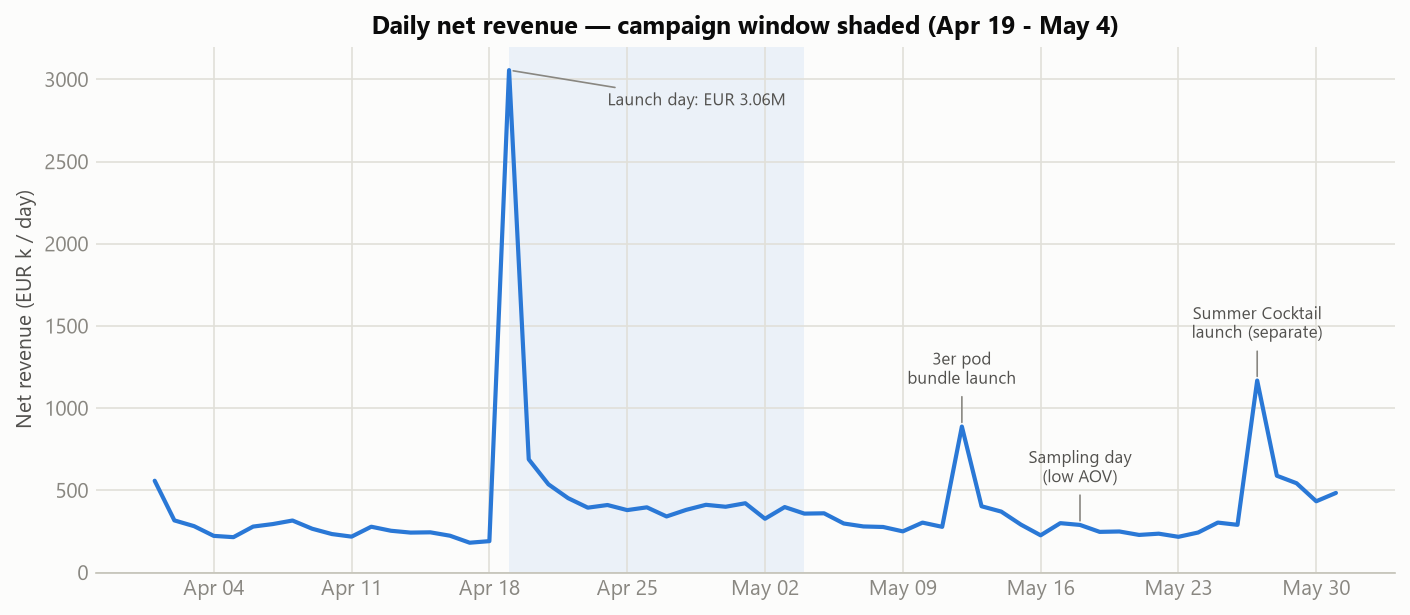

In [28]:
day = o.groupby("order_date").net_revenue.sum() / 1000
fig, ax = plt.subplots(figsize=(9.5, 4.2), dpi=150)
ax.axvspan(pd.Timestamp("2026-04-19"), pd.Timestamp("2026-05-04"), color=BLUE, alpha=0.08, lw=0)
ax.plot(day.index, day.values, color=BLUE, lw=2, solid_capstyle="round")
ax.set_ylim(0, None); ax.set_ylabel("Net revenue (EUR k / day)")
ax.set_title("Daily net revenue — campaign window shaded (Apr 19 - May 4)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d")); ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
v19 = day.loc[pd.Timestamp("2026-04-19")]
ax.annotate(f"Launch day: EUR {v19/1000:.2f}M", (pd.Timestamp("2026-04-19"), v19), xytext=(pd.Timestamp("2026-04-24"), v19 * 0.93),
            fontsize=8, color=SEC, ha="left", arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
for d, label in [("2026-05-12", "3er pod\nbundle launch"), ("2026-05-27", "Summer Cocktail\nlaunch (separate)"), ("2026-05-18", "Sampling day\n(low AOV)")]:
    v = day.loc[pd.Timestamp(d)]
    ax.annotate(label, (pd.Timestamp(d), v), xytext=(pd.Timestamp(d), v + 260), fontsize=8, color=SEC,
                ha="center", arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.tick_params(length=0); fig.tight_layout()
fig.savefig("charts/daily_revenue.png", facecolor=SURFACE)
plt.show()

### 4.2 Daily syrup bottle units (full scale + zoom)

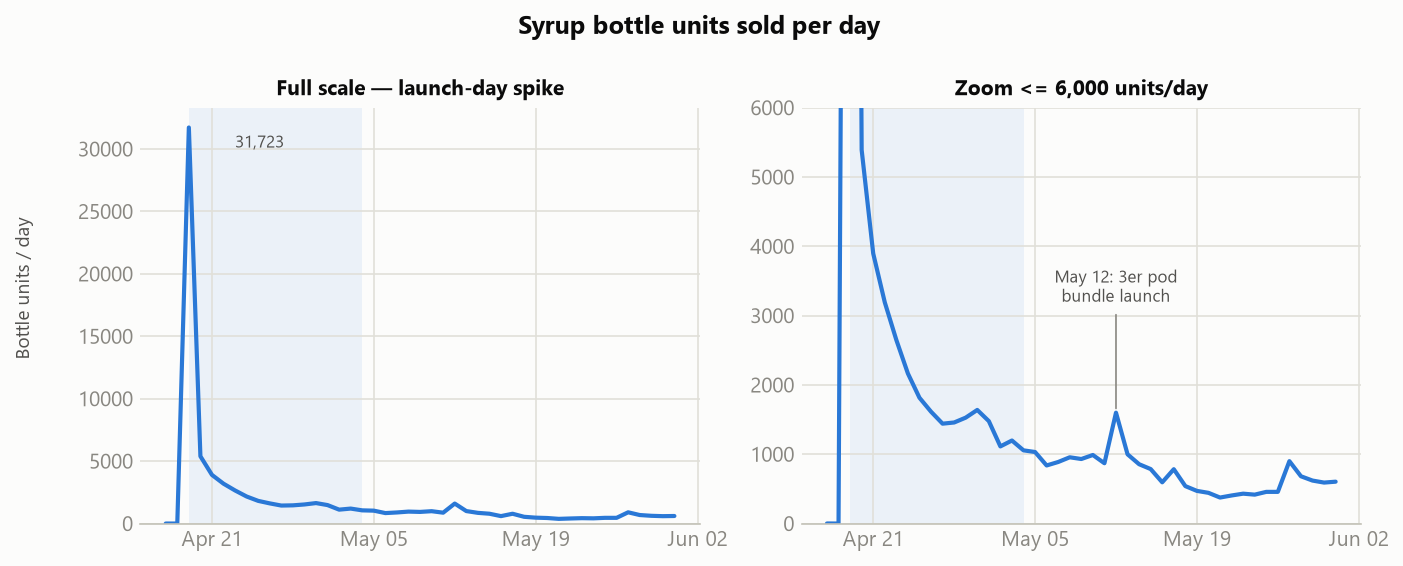

In [29]:
bd = daily_bottles.reindex(pd.date_range("2026-04-17", "2026-05-31"), fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), dpi=150)
for ax, ylim, title in [(axes[0], None, "Full scale — launch-day spike"), (axes[1], 6000, "Zoom <= 6,000 units/day")]:
    ax.axvspan(pd.Timestamp("2026-04-19"), pd.Timestamp("2026-05-04"), color=BLUE, alpha=0.08, lw=0)
    ax.plot(bd.index, bd.values, color=BLUE, lw=2, solid_capstyle="round")
    ax.set_ylim(0, ylim); ax.set_title(title, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d")); ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
    ax.tick_params(length=0)
axes[0].annotate(f"{int(bd.max()):,}", (pd.Timestamp("2026-04-19"), bd.max()), fontsize=8, color=SEC,
                 ha="left", va="top", xytext=(pd.Timestamp("2026-04-23"), bd.max() * 0.98))
v12 = bd.loc[pd.Timestamp("2026-05-12")]
axes[1].annotate("May 12: 3er pod\nbundle launch", (pd.Timestamp("2026-05-12"), v12), fontsize=8, color=SEC,
                 ha="center", xytext=(pd.Timestamp("2026-05-12"), 3200), arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
fig.suptitle("Syrup bottle units sold per day", fontweight="bold", fontsize=12, color=INK)
fig.supylabel("Bottle units / day", fontsize=9, color=SEC)
fig.tight_layout(rect=[0.02, 0, 1, 0.99])
fig.savefig("charts/daily_bottles.png", facecolor=SURFACE)
plt.show()

### 4.3 Syrup adoption by market

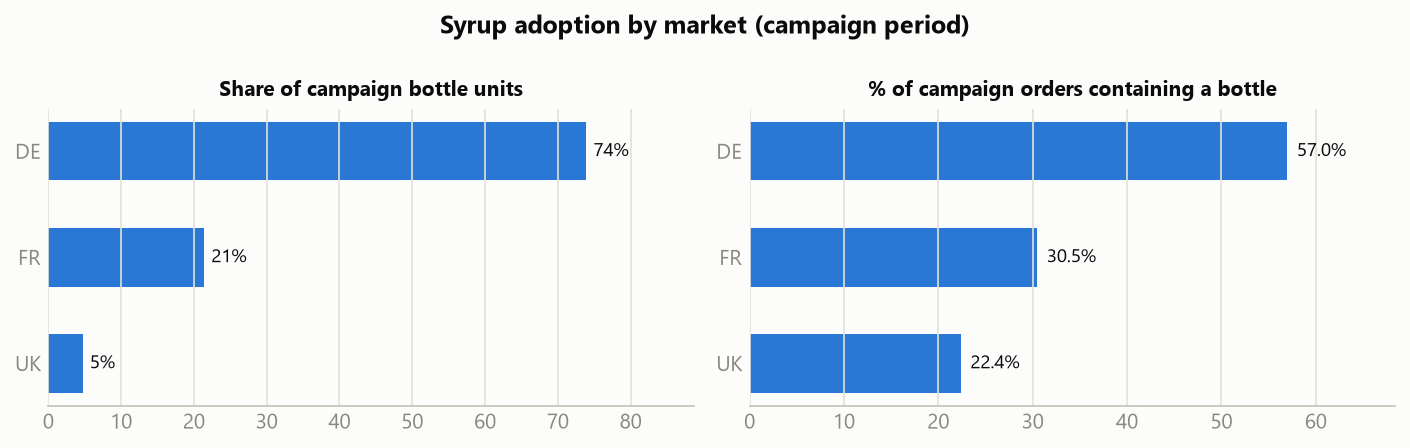

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.0), dpi=150)
for ax, col, title, fmt in [(axes[0], "units_share", "Share of campaign bottle units", "{:.0f}%"),
                            (axes[1], "penetration_pct", "% of campaign orders containing a bottle", "{:.1f}%")]:
    vals = mk[col].reindex(["UK", "FR", "DE"])
    bars = ax.barh(vals.index, vals.values, color=BLUE, height=0.55)
    for b, v in zip(bars, vals.values):
        ax.text(v + 1, b.get_y() + b.get_height() / 2, fmt.format(v), va="center", fontsize=9, color=INK)
    ax.set_title(title, fontsize=10); ax.set_xlim(0, vals.max() * 1.2)
    ax.grid(axis="y", visible=False); ax.tick_params(length=0)
fig.suptitle("Syrup adoption by market (campaign period)", fontweight="bold", fontsize=12, color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig("charts/market_breakdown.png", facecolor=SURFACE)
plt.show()

### 4.4 Delivery delay vs reorder rate (the money chart)

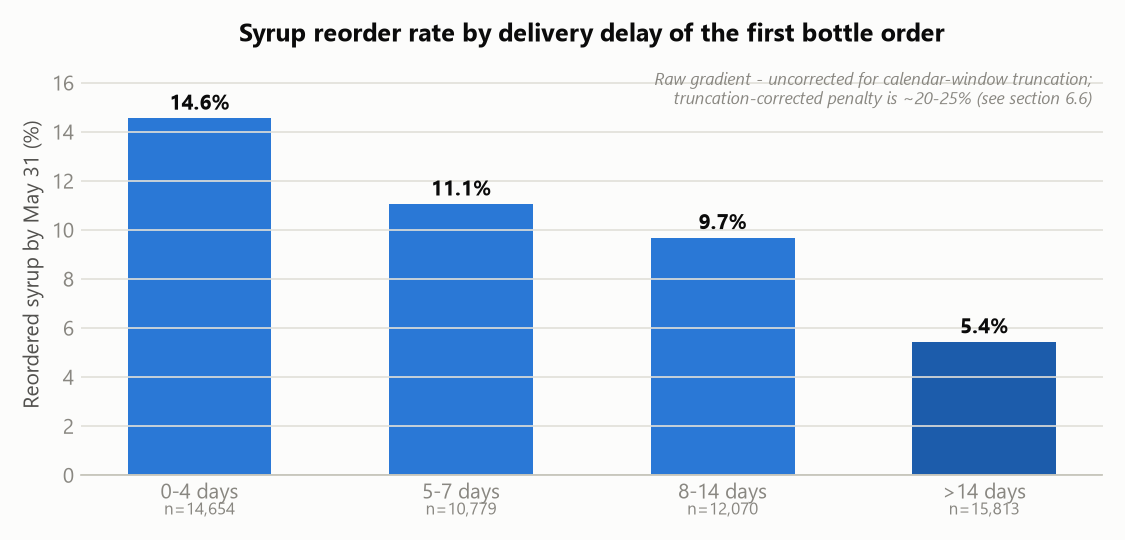

In [31]:
labels = {"0-4d": "0-4 days", "5-7d": "5-7 days", "8-14d": "8-14 days", ">14d": ">14 days"}
rates = delay_tbl.reorder_rate * 100
fig, ax = plt.subplots(figsize=(7.5, 3.6), dpi=150)
bars = ax.bar([labels[i] for i in delay_tbl.index], rates, color=[BLUE, BLUE, BLUE, BLUE_D], width=0.55)
for b, r, n in zip(bars, rates, delay_tbl.n):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.35, f"{r:.1f}%", ha="center", fontsize=10, color=INK, fontweight="bold")
    ax.text(b.get_x() + b.get_width() / 2, -1.6, f"n={n:,}", ha="center", fontsize=8, color=MUTED)
ax.set_ylim(0, rates.max() * 1.18)
ax.set_title("Syrup reorder rate by delivery delay of the first bottle order")
ax.set_ylabel("Reordered syrup by May 31 (%)")
ax.grid(axis="x", visible=False); ax.tick_params(length=0)
ax.text(0.99, 0.96, "Raw gradient - uncorrected for calendar-window truncation;\n"
                    "truncation-corrected penalty is ~20-25% (see section 6.6)",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color=MUTED, style="italic")
fig.tight_layout()
fig.savefig("charts/delay_vs_reorder.png", facecolor=SURFACE)
plt.show()

<a id="sec5"></a>
## 5. Question 2 — H2 budget (analysis of the CMO memo)

Question 2 uses no CSV data: its inputs are the tables in `case-materials/1782235684569_holy_cmo_memo_mmm_h2_2026.pdf`.
This section makes that work auditable: the PDF is extracted (§5.1), its tables are transcribed into
DataFrames exactly as printed in the memo (§5.2), and every derived number quoted in
[q2-h2-budget-plan.md](docs/q2-h2-budget-plan.md) — the €35M-vs-€16.1M tension, the mROI ranking, the
MMM-vs-attribution conflicts, and the allocation checksums — is computed below (§5.3–5.4).
The *qualitative* parts (testing roadmap, assumptions, missing context) live in the write-up only, since
they are reasoning, not computation.

<a id="sec51"></a>
### 5.1 Extracting the memo PDF

The memo is a text-based PDF; `pypdf` extracts it losslessly. All numbers in §5.2 were transcribed from this
output (and can be checked against it here).

In [32]:
from pypdf import PdfReader

reader = PdfReader("case-materials/1782235684569_holy_cmo_memo_mmm_h2_2026.pdf")
memo_text = "\n".join(f"--- PAGE {i+1} ---\n" + page.extract_text() for i, page in enumerate(reader.pages))
print(f"{len(reader.pages)} pages | {len(memo_text):,} characters extracted\n")
print(memo_text[:1200])  # excerpt: model card + start of the L1 results table

3 pages | 7,606 characters extracted

--- PAGE 1 ---
CMO Memo on H2 2026 Planning
H2 2026 Media Budget Recommendation
To CMO & Marketing Leadership Team
From MMM Team
Date 11 June 2026
Subject MMM v5.3.1 results & H2 2026 budget allocation (constrained scenario)
2. The Model Behind the Numbers — MMM v5.3.1
Method Ridge regression, non-negative media effects, with adstock (carry-over) and saturation (diminishingreturns) per channel
Data 125 weeks: Jan 2024 – May 2026 — first refresh to include full H1 2026
Hyperparameter tuningAutomated 400-trial Bayesian (Optuna) search
Validation design29-week out-of-sample holdout (Nov 2025 – May 2026), spanning Black Week + Christmas + Q1
Fit Train R² = 0.68 · Holdout R² = 0.29 (passes hard gate ≥ 0.2) · Holdout WAPE 27.7%
Verdict USABLE FOR STEERING — both hard acceptance gates passed
What's new vs the previous production model: newer data (through May 2026), calendar-anchored validation guaranteeing Black Week is tested out-of-sample, and sub-chan

<a id="sec52"></a>
### 5.2 The memo's tables, transcribed as data

Values are copied 1:1 from the memo (verifiable against the §5.1 extraction).
Spend/contribution in €M over the 125 modeled weeks (Jan 2024 – May 2026) unless noted.

In [33]:
# Section A - MMM v5.3.1, L1 channel results (memo section 3.1)
mmm_l1 = pd.DataFrame([
    ("Paid Social",   15.01, 30.65, 2.04, 1.50),
    ("Influencer",    24.10, 25.30, 1.05, 0.40),
    ("Brand",          7.55,  7.87, 1.04, 0.44),
    ("Google Search",  0.66,  2.68, 4.09, 4.46),
    ("Affiliate",      0.59,  2.69, 4.60, 1.78),
], columns=["channel", "spend_125wk_M", "incr_revenue_M", "iROAS", "mROI"])

# L2 sub-channel tables (memo sections 4.1-4.3)
ps_l2 = pd.DataFrame([
    ("META",    11.12, 13.27, 1.19,  0.99, "OK"),
    ("TikTok",   3.81, 14.57, 3.82,  1.35, "OK"),
    ("YouTube",  0.07,  2.82, 37.1, 20.00, "LOW - directional only"),
], columns=["platform", "spend_M", "contribution_M", "iROAS", "mROI", "confidence"])

inf_l2 = pd.DataFrame([
    ("YouTube Influencer", 11.95, 8.81, 0.74, 0.30),
    ("Twitch",              5.11, 5.72, 1.12, 0.43),
    ("Instagram",           3.50, 4.62, 1.32, 0.52),
    ("Podcast",             1.87, 3.18, 1.70, 0.71),
    ("TikTok Influencer",   1.67, 2.96, 1.78, 0.76),
], columns=["platform", "spend_M", "contribution_M", "iROAS", "mROI"])

brand_l2 = pd.DataFrame([
    ("Events / Sponsoring",   1.87, 3.25, 1.74),
    ("TV Ads",                1.28, 1.43, 1.12),
    ("OOH",                   0.83, 0.81, 0.97),
    ("Streaming",             0.62, 0.57, 0.92),
    ("Influencer Awareness",  2.13, 1.46, 0.69),
    ("Performance Awareness", 0.81, 0.35, 0.43),
], columns=["sub_channel", "spend_M", "contribution_M", "iROAS_8wk"])

# H1 2026 actual run-rates and the MMM team's own H2 plan (memo section 5.2), EUR per week
h1_h2 = pd.DataFrame([
    ("Paid Social",   228609, 268103, 6970678),
    ("Influencer",    268817, 202388, 5262080),
    ("Brand",         222771, 120326, 3128460),
    ("Google Search",   5765,  11923,  310000),
    ("Affiliate",      17779,  17779,  462259),
], columns=["channel", "h1_actual_wk", "memo_h2_plan_wk", "memo_h2_total"])

# Section B - DE attribution, March-May 2026 (cost in EUR K)
attr = pd.DataFrame([
    ("2026-03", "DE Influencer", 1354, 25227,  53.7, 54.40), ("2026-03", "DE Meta Paid",  847, 9989, 84.8, 47.70),
    ("2026-03", "DE TikTok Paid", 304,  2209, 137.5, 48.00), ("2026-03", "DE Affiliate",   98, 3593, 27.2, 44.60),
    ("2026-03", "DE other (paid)", 70,  7140,   9.7,  None),
    ("2026-04", "DE Influencer", 1003, 16799,  59.7, 56.57), ("2026-04", "DE Meta Paid",  670, 7666, 87.3, 49.23),
    ("2026-04", "DE TikTok Paid", 175,  1365, 128.0, 50.20), ("2026-04", "DE Affiliate",   43, 3101, 13.9, 40.90),
    ("2026-04", "DE other (paid)", 169, 3783,  44.6,  None),
    ("2026-05", "DE Influencer", 1145, 20406,  56.1, 54.20), ("2026-05", "DE Meta Paid",  620, 5930, 104.6, 48.30),
    ("2026-05", "DE TikTok Paid", 216,  1065, 203.2, 50.90), ("2026-05", "DE Affiliate",   76, 4620, 16.5, 44.00),
    ("2026-05", "DE other (paid)", 73,  7010,  10.4,  None),
], columns=["month", "channel", "cost_k", "attributed_nc", "cac", "clv6m"])
attr["clv6m_over_cac"] = (attr.clv6m / attr.cac).round(2)

display(mmm_l1)
display(ps_l2)
print("(inf_l2, brand_l2, h1_h2, attr defined - displayed where used below)")

,channel,spend_125wk_M,incr_revenue_M,iROAS,mROI
0,Paid Social,15.01,30.65,2.04,1.50
1,Influencer,24.10,25.30,1.05,0.40
2,Brand,7.55,7.87,1.04,0.44
3,Google Search,0.66,2.68,4.09,4.46
4,Affiliate,0.59,2.69,4.60,1.78


,platform,spend_M,contribution_M,iROAS,mROI,confidence
0,META,11.12,13.27,1.19,0.99,OK
1,TikTok,3.81,14.57,3.82,1.35,OK
2,YouTube,0.07,2.82,37.10,20.00,LOW - directional only


(inf_l2, brand_l2, h1_h2, attr defined - displayed where used below)


<a id="sec53"></a>
### 5.3 Derived analysis — the numbers behind the write-up's argument

In [34]:
# (a) The elephant in the room: EUR 35M vs what the model itself recommends
h1_half_total = h1_h2.h1_actual_wk.sum() * 26 / 1e6
memo_h2_total = h1_h2.memo_h2_total.sum() / 1e6
print(f"H1 2026 actual media spend (26 wk):     EUR {h1_half_total:5.1f}M")
print(f"MMM team's optimised H2 plan:           EUR {memo_h2_total:5.1f}M  ({memo_h2_total/h1_half_total-1:+.0%} vs H1)")
print(f"Task budget:                            EUR  35.0M  = {35/memo_h2_total:.1f}x the model-optimal level, {35/h1_half_total-1:+.0%} vs H1")

# (b) mROI ranking - the allocation ordering used in Task 1
print("\nL1 channels ranked by marginal ROI (scale first at the top):")
display(mmm_l1.sort_values("mROI", ascending=False)[["channel", "iROAS", "mROI"]])

# (c) Saturation warning: the memo's own mROI-at-plan figures (section 6.1) show PS drops below 1 quickly
sat = pd.DataFrame([("META", "+8%", 0.99, 0.95), ("TikTok", "+50%", 1.35, 0.63), ("YouTube", "+100%", 20, 7.1)],
                   columns=["platform", "memo_planned_increase", "mROI_today", "mROI_at_plan"])
display(sat)
print("-> even the memo's modest increases push mROI below 1; EUR 31M of performance spend is far past that")

H1 2026 actual media spend (26 wk):     EUR  19.3M
MMM team's optimised H2 plan:           EUR  16.1M  (-17% vs H1)
Task budget:                            EUR  35.0M  = 2.2x the model-optimal level, +81% vs H1

L1 channels ranked by marginal ROI (scale first at the top):


,channel,iROAS,mROI
3,Google Search,4.09,4.46
4,Affiliate,4.60,1.78
0,Paid Social,2.04,1.50
2,Brand,1.04,0.44
1,Influencer,1.05,0.40


,platform,memo_planned_increase,mROI_today,mROI_at_plan
0,META,+8%,0.99,0.95
1,TikTok,+50%,1.35,0.63
2,YouTube,+100%,20.00,7.10


-> even the memo's modest increases push mROI below 1; EUR 31M of performance spend is far past that


In [35]:
# (d) The MMM-vs-attribution conflict - why tests 1, 3 and 4 of the roadmap exist
may = attr[attr.month == "2026-05"].set_index("channel")
conflict = pd.DataFrame({
    "MMM_mROI":        {"DE Influencer": 0.40, "DE Meta Paid": 0.99, "DE TikTok Paid": 1.35},
    "attr_CAC_may":    may.cac, "attr_CLV6M/CAC": may.clv6m_over_cac,
}).dropna()
conflict["disagreement"] = ["MMM: worst channel / attribution: efficient volume star",
                            "MMM: breakeven / attribution: pays back <50% in 6 months",
                            "MMM: best scalable channel / attribution: worst CAC"]
display(conflict)

# (e) Attribution health checks quoted in Task 3: blended CAC drift + the implausible 'DE other'
monthly = attr.groupby("month").agg(cost_k=("cost_k", "sum"), nc=("attributed_nc", "sum"))
monthly["blended_CAC"] = (monthly.cost_k * 1000 / monthly.nc).round(1)
display(monthly)
other = attr[attr.channel == "DE other (paid)"][["month", "cost_k", "attributed_nc", "cac"]]
print("'DE other (paid)' - implausibly cheap NCs, excluded from decisions:")
display(other)

,MMM_mROI,attr_CAC_may,attr_CLV6M/CAC,disagreement
DE Influencer,0.40,56.1,0.97,MMM: worst channel / attribution: efficient vo...
DE Meta Paid,0.99,104.6,0.46,MMM: breakeven / attribution: pays back <50% i...
DE TikTok Paid,1.35,203.2,0.25,MMM: best scalable channel / attribution: wors...


,cost_k,nc,blended_CAC
month,,,
2026-03,2673,48158,55.5
2026-04,2060,32714,63.0
2026-05,2130,39031,54.6


'DE other (paid)' - implausibly cheap NCs, excluded from decisions:


,month,cost_k,attributed_nc,cac
4,2026-03,70,7140,9.7
9,2026-04,169,3783,44.6
14,2026-05,73,7010,10.4


<a id="sec54"></a>
### 5.4 Task 1 allocation — arithmetic and constraint checksums

The *choice* of these numbers follows the logic in the write-up (mROI ranking, gated scaling of
Google/Affiliate, forced Influencer envelope, testing reserve); this cell proves the plan satisfies every
constraint: €35M total = €4M brand (incl. €0.8M TV locked in Q3) + €31M performance.

In [36]:
alloc = pd.Series({
    # performance envelope (EUR M)
    "Paid Social - META":            10.00,
    "Paid Social - TikTok":           5.50,
    "Paid Social - YouTube (test)":   1.50,
    "Influencer (mix-shifted)":       9.60,
    "Google Search (test-gated)":     1.00,
    "Affiliate (test-gated)":         0.90,
    "Testing & flex reserve":         2.50,
    # brand envelope (fixed EUR 4M)
    "Brand - TV Q3 (locked)":         0.80,
    "Brand - Events / Sponsoring":    1.50,
    "Brand - TV Q4 top-up":           0.60,
    "Brand - OOH":                    0.40,
    "Brand - Streaming":              0.25,
    "Brand - Influencer Awareness":   0.30,
    "Brand - Performance Awareness":  0.15,
}, name="EUR M")

brand = alloc[alloc.index.str.startswith("Brand")]
perf  = alloc[~alloc.index.str.startswith("Brand")]
print(f"brand envelope:      {brand.sum():5.2f}  (constraint:  4.00, incl. 0.80 TV locked in Q3)")
print(f"performance flexible:{perf.sum():6.2f}  (constraint: 31.00)")
print(f"TOTAL:               {alloc.sum():5.2f}  (constraint: 35.00)")
assert round(brand.sum(), 2) == 4.00 and round(perf.sum(), 2) == 31.00 and round(alloc.sum(), 2) == 35.00
display(alloc.to_frame())

# vs H1 half-year actuals per L1 channel
cmp = pd.DataFrame({"h1_actual_M": (h1_h2.set_index("channel").h1_actual_wk * 26 / 1e6).round(2)})
cmp["h2_plan_M"] = [10.0 + 5.5 + 1.5, 9.6, 4.0, 1.0, 0.9]
cmp["change"] = (cmp.h2_plan_M / cmp.h1_actual_M - 1).map("{:+.0%}".format)
display(cmp)

# quarterly phasing (Q4-weighted for Black Week / Christmas)
phasing = pd.DataFrame({"Q3": [12.0, 2.2], "Q4": [19.0, 1.8]}, index=["Performance", "Brand"])
phasing.loc["Total"] = phasing.sum()
display(phasing)
print("Q4 share of performance spend:", f"{19.0/31.0:.0%}", "- tests run in Q3, validated winners scale in Q4")

brand envelope:       4.00  (constraint:  4.00, incl. 0.80 TV locked in Q3)
performance flexible: 31.00  (constraint: 31.00)
TOTAL:               35.00  (constraint: 35.00)


,EUR M
Paid Social - META,10.00
Paid Social - TikTok,5.50
Paid Social - YouTube (test),1.50
Influencer (mix-shifted),9.60
Google Search (test-gated),1.00
Affiliate (test-gated),0.90
Testing & flex reserve,2.50
Brand - TV Q3 (locked),0.80
Brand - Events / Sponsoring,1.50
Brand - TV Q4 top-up,0.60


,h1_actual_M,h2_plan_M,change
channel,,,
Paid Social,5.94,17.0,+186%
Influencer,6.99,9.6,+37%
Brand,5.79,4.0,-31%
Google Search,0.15,1.0,+567%
Affiliate,0.46,0.9,+96%


,Q3,Q4
Performance,12.0,19.0
Brand,2.2,1.8
Total,14.2,20.8


Q4 share of performance spend: 61% - tests run in Q3, validated winners scale in Q4


<a id="sec6"></a>
## 6. Further analysis — beyond the brief's guiding questions

Analyses the case does not explicitly request but that materially sharpen (and in one case **revise**) the
conclusions. Written up in [further-analysis.md](docs/further-analysis.md).

<a id="sec61"></a>
### 6.1 Refunds & cancellations — did the delays trigger immediate revenue give-back?

In [37]:
camp_od = od[od.period == "2_campaign"].copy()
print("partial-refund incidence (refunded_value > 0 among active orders): bottle {:.2%} vs non-bottle {:.2%}".format(
    (camp_od[camp_od.has_bottle].refunded_value > 0).mean(), (camp_od[~camp_od.has_bottle].refunded_value > 0).mean()))
camp_od["delay_bucket"] = pd.cut(camp_od.lag, [-1, 4, 7, 14, 100], labels=["0-4d", "5-7d", "8-14d", ">14d"])
display(camp_od[camp_od.has_bottle].groupby("delay_bucket", observed=True)
        .agg(n=("order_id", "count"), refund_rate=("refunded_value", lambda s: (s > 0).mean())).round(4))

# cancellation rate (rule provided by Martijn: refunded >= gross) - cancelled orders back in scope for the denominator
allo = orders.copy()
allo["period"] = allo.order_date.apply(period)
allo["has_bottle"] = allo.order_id.isin(set(items_raw[items_raw.component_sku.isin(BOTTLES)].order_id))
ca = allo[allo.period == "2_campaign"]
cb_rate, cn_rate = ca[ca.has_bottle].cancelled.mean(), ca[~ca.has_bottle].cancelled.mean()
print("cancellation rate (full refund), campaign: bottle {:.2%} vs non-bottle {:.2%} ({:.1f}x)".format(cb_rate, cn_rate, cb_rate / cn_rate))
rts = set(ship.loc[ship.delivery_status == "Returned to sender", "order_id"])
print("returned-to-sender: bottle {:.3%} vs non-bottle {:.3%}".format(
    camp[camp.has_bottle].order_id.isin(rts).mean(), camp[~camp.has_bottle].order_id.isin(rts).mean()))
print("\n-> refunds are small and do not rise with delay; bottle orders almost never cancel (0.02% vs 0.36%).")
print("   The cost of the production gap was retention (section 3.10), not immediate give-back.")

partial-refund incidence (refunded_value > 0 among active orders): bottle 1.28% vs non-bottle 0.27%


,n,refund_rate
delay_bucket,,
0-4d,15068,0.0042
5-7d,11119,0.0051
8-14d,12371,0.0048
>14d,16540,0.0023


cancellation rate (full refund), campaign: bottle 0.02% vs non-bottle 0.36% (0.1x)
returned-to-sender: bottle 0.013% vs non-bottle 0.046%

-> refunds are small and do not rise with delay; bottle orders almost never cancel (0.02% vs 0.36%).
   The cost of the production gap was retention (section 3.10), not immediate give-back.


<a id="sec62"></a>
### 6.2 Did the May 18 sampling giveaway convert?

Fixed 13-day window for every cohort (May 18 buyers have exactly 13 days of data left), so the comparison is fair.

In [38]:
firsts = o[o.is_first_order & o.customer_id.notna()].sort_values("order_date").groupby("customer_id").first().reset_index()
paid = o.loc[o.gross_revenue > 0, ["customer_id", "order_date"]].dropna()

def paid_conversion_within(cohort_df, days=13):
    m = paid.merge(cohort_df[["customer_id", "order_date"]].rename(columns={"order_date": "fd"}), on="customer_id")
    m = m[(m.order_date > m.fd) & (m.order_date <= m.fd + pd.Timedelta(days=days))]
    return m.customer_id.nunique() / len(cohort_df)

d18_free = firsts[(firsts.order_date == "2026-05-18") & (firsts.gross_revenue == 0)]
ctrl_new = firsts[(firsts.order_date >= "2026-05-11") & (firsts.order_date <= "2026-05-17") & (firsts.gross_revenue > 0)]
print(f"May 18 free-sample new customers   n={len(d18_free):6,}  paid order within 13d: {paid_conversion_within(d18_free):.2%}")
print(f"control: paying new (May 11-17)    n={len(ctrl_new):6,}  repeat paid within 13d: {paid_conversion_within(ctrl_new):.2%}")
print("\n-> the giveaway converted ~13x worse than organically-acquired new customers in the same window.")
print("   Caveat: 13 days is short; CRM follow-up on these 5.4k leads may still monetise them.")

May 18 free-sample new customers   n= 5,405  paid order within 13d: 0.37%
control: paying new (May 11-17)    n=12,812  repeat paid within 13d: 4.82%

-> the giveaway converted ~13x worse than organically-acquired new customers in the same window.
   Caveat: 13 days is short; CRM follow-up on these 5.4k leads may still monetise them.


<a id="sec63"></a>
### 6.3 Quality of campaign-acquired new customers

Fixed 21-day repeat window per cohort (all first orders are >=21 days before the data ends).

In [39]:
all_orders_cust = o[["customer_id", "order_date"]].dropna()

def repeat_within(cohort_df, days=21):
    m = all_orders_cust.merge(cohort_df[["customer_id", "order_date"]].rename(columns={"order_date": "fd"}), on="customer_id")
    m = m[(m.order_date > m.fd) & (m.order_date <= m.fd + pd.Timedelta(days=days))]
    return m.customer_id.nunique() / len(cohort_df)

firsts["has_bottle"] = firsts.order_id.isin(set(bot.order_id))
in_camp = (firsts.order_date >= "2026-04-19") & (firsts.order_date <= "2026-05-04")
cohorts = {"campaign new WITH bottle": firsts[in_camp & firsts.has_bottle],
           "campaign new, no bottle":  firsts[in_camp & ~firsts.has_bottle],
           "pre-period new (baseline)": firsts[firsts.order_date <= "2026-04-18"]}
for name, c in cohorts.items():
    print(f"{name:28s} n={len(c):6,}  repeat (any order) within 21d: {repeat_within(c):.2%}")
print("\n-> syrup-acquired new customers repeat LESS in 21 days, not more. Caveats: the syrup refill cycle")
print("   is ~23 days (section 3.10) and many had delayed deliveries - but at face value it weakens the")
print("   'syrup as acquisition tool' idea further: it neither pulls volume nor (so far) better cohorts.")

campaign new WITH bottle     n=12,570  repeat (any order) within 21d: 4.51%
campaign new, no bottle      n=32,783  repeat (any order) within 21d: 8.55%


pre-period new (baseline)    n=33,788  repeat (any order) within 21d: 9.32%

-> syrup-acquired new customers repeat LESS in 21 days, not more. Caveats: the syrup refill cycle
   is ~23 days (section 3.10) and many had delayed deliveries - but at face value it weakens the
   'syrup as acquisition tool' idea further: it neither pulls volume nor (so far) better cohorts.


<a id="sec64"></a>
### 6.4 Warehouse split — where the production gap actually lived

In [40]:
fs_wh = ship[ship.delivered_at.notna()].sort_values("delivered_at").groupby("order_id").head(1)
odw = o.merge(fs_wh[["order_id", "delivered_at", "warehouse"]], on="order_id", how="left")
odw["lag"] = (odw.delivered_at - odw.order_date).dt.days
cw = odw[(odw.period == "2_campaign") & odw.has_bottle]
print("campaign BOTTLE orders, delivery lag by warehouse:")
display(cw.groupby("warehouse").lag.agg(["count", "median", "mean"]).round(1))
print("non-bottle campaign orders for comparison:")
display(odw[(odw.period == "2_campaign") & ~odw.has_bottle].groupby("warehouse").lag.agg(["count", "median"]))
print("-> the gap was a POZ1 problem (median 8d, mean 13d on bottles); NOT1 shipped bottles in ~4 days")
print("   throughout. The ops fix is warehouse-specific, not network-wide.")

campaign BOTTLE orders, delivery lag by warehouse:


,count,median,mean
warehouse,,,
NOT1,2856,4.0,4.0
POZ1,52242,8.0,13.3


non-bottle campaign orders for comparison:


,count,median
warehouse,,
NOT1,9835,3.0
POZ1,58853,5.0


-> the gap was a POZ1 problem (median 8d, mean 13d on bottles); NOT1 shipped bottles in ~4 days
   throughout. The ops fix is warehouse-specific, not network-wide.


<a id="sec65"></a>
### 6.5 Habit formation — did the bottle change overall engagement?

Same cohort contrast as the cannibalisation check (§3.11) but on **total** spend and order frequency.

In [41]:
for name, grp in [("bottle buyers (existing)", eb), ("control (existing, no bottle)", ctrl)]:
    sub = o[o.customer_id.isin(grp)]
    pre, post = sub[sub.period == "1_pre"], sub[sub.period == "3_post"]
    print(f"{name:30s} n={len(grp):6,} | total net/day pre {pre.net_revenue.sum()/18:7,.0f} -> post {post.net_revenue.sum()/27:7,.0f} "
          f"({post.net_revenue.sum()/27/(pre.net_revenue.sum()/18)-1:+.0%}) | orders/day {len(pre)/18:5.0f} -> {len(post)/27:5.0f}")
print("\n-> bottle buyers nearly doubled their total activity post-campaign while the control declined.")
print("   Note the bottle cohort was LESS active pre-campaign (13.0k vs 17.3k gross/day from MORE customers):")
print("   the launch re-activated dormant existing customers - and they stayed active. Interpretation caveat:")
print("   part of the lift is syrup refills themselves + regression to the mean; a matched-activity control")
print("   would be needed to size the pure habit effect.")

bottle buyers (existing)       n=41,586 | total net/day pre  12,098 -> post  22,841 (+89%) | orders/day   151 ->   281


control (existing, no bottle)  n=33,613 | total net/day pre  15,969 -> post  15,149 (-5%) | orders/day   277 ->   190

-> bottle buyers nearly doubled their total activity post-campaign while the control declined.
   Note the bottle cohort was LESS active pre-campaign (13.0k vs 17.3k gross/day from MORE customers):
   the launch re-activated dormant existing customers - and they stayed active. Interpretation caveat:
   part of the lift is syrup refills themselves + regression to the mean; a matched-activity control
   would be needed to size the pure habit effect.


<a id="sec66"></a>
### 6.6 Truncation-corrected delay effect — an honest revision of §3.10

The raw gradient (14.5% -> 5.4%) mixes the delay effect with calendar truncation: late-delivered customers
simply had fewer days left before May 31 to reorder. Fix: give every customer the **same 21-day clock
starting at delivery**, restricted to deliveries by May 10 so every window completes.

In [42]:
cb21 = cohort.merge(od[["order_id", "lag", "delivered_at"]], on="order_id", how="left")
cb21 = cb21[cb21.delivered_at <= "2026-05-10"]
first_reorder = later.groupby("customer_id").order_date.min().rename("first_reorder")
cb21 = cb21.merge(first_reorder, on="customer_id", how="left")
cb21["reorder_21d_of_delivery"] = cb21.first_reorder <= cb21.delivered_at + pd.Timedelta(days=21)
cb21["delay_bucket"] = pd.cut(cb21.lag, [-1, 4, 7, 14, 100], labels=["0-4d", "5-7d", "8-14d", ">14d"])
corr = cb21.groupby("delay_bucket", observed=True).agg(n=("customer_id", "count"), reorder_rate=("reorder_21d_of_delivery", "mean"))
display(corr.round(4))

best = corr.reorder_rate.iloc[0]
lost_corr = (corr.n * (best - corr.reorder_rate)).clip(lower=0).sum()
delayed_full = (cb.lag > 4).sum()          # full cohort with lag > 4d, from section 3.10
lost_scaled = lost_corr / (corr.n.iloc[1:].sum()) * delayed_full
print(f"corrected penalty: ~{best - corr.reorder_rate.iloc[1:].mean():.1%}pts (~{1 - corr.reorder_rate.iloc[1:].mean()/best:.0%} relative), "
      f"scaled to the full delayed cohort: ~{lost_scaled:,.0f} lost reorders")
print("-> the delay effect is real and material but IMPRECISELY estimated: note the corrected gradient is not")
print("   monotonic (the >14d bucket - which, restricted to early deliveries, holds the most enthusiastic")
print("   launch-day buyers - sits at 8.0%, above 8-14d). Treat the penalty as roughly a fifth to a quarter")
print("   lower reorder likelihood (~1,000 lost reorders), not a point estimate; naive read was ~2,400.")

,n,reorder_rate
delay_bucket,,
0-4d,14654,0.0987
5-7d,10747,0.0745
8-14d,11731,0.0713
>14d,6606,0.0801


corrected penalty: ~2.3%pts (~24% relative), scaled to the full delayed cohort: ~938 lost reorders
-> the delay effect is real and material but IMPRECISELY estimated: note the corrected gradient is not
   monotonic (the >14d bucket - which, restricted to early deliveries, holds the most enthusiastic
   launch-day buyers - sits at 8.0%, above 8-14d). Treat the penalty as roughly a fifth to a quarter
   lower reorder likelihood (~1,000 lost reorders), not a point estimate; naive read was ~2,400.


<a id="sec67"></a>
### 6.7 Refill-demand forecast — a planning number for production

In [43]:
fast = cb21[cb21.delay_bucket == "0-4d"]          # well-served owners = steady-state behaviour
p21 = fast.reorder_21d_of_delivery.mean()
refills_per_1k_month = p21 * 30 / 21 * 1000
packs_per_refill = later.groupby(["customer_id", "order_id"]).quantity.sum().mean()
print(f"well-served owners reordering within 21d of delivery: {p21:.1%}")
print(f"=> per 1,000 bottle owners: ~{refills_per_1k_month:,.0f} refill orders/month x {packs_per_refill:.1f} packs = "
      f"~{refills_per_1k_month * packs_per_refill:,.0f} pod packs/month")
print("First-month estimate from launch-cohort behaviour; refine with June+ data as the cohort matures.")

well-served owners reordering within 21d of delivery: 9.9%
=> per 1,000 bottle owners: ~141 refill orders/month x 3.6 packs = ~505 pod packs/month
First-month estimate from launch-cohort behaviour; refine with June+ data as the cohort matures.
